In [ ]:
import pandas as pd
data=pd.read_csv("student_performance_encoded.csv")
print(data)

print(data.shape)
print(data.columns)

     Year  cgpa  Academic_Satisfaction  Daily_study_hours  Revision_frequency  \
0     1.0   2.0                    2.0                0.0                 0.0   
1     1.0   2.0                    1.0                1.0                 1.0   
2     1.0   0.0                    2.0                1.0                 2.0   
3     1.0   2.0                    3.0                1.0                 1.0   
4     1.0   2.0                    2.0                1.0                 1.0   
..    ...   ...                    ...                ...                 ...   
768   2.0   0.0                    2.0                1.0                 1.0   
769   1.0   1.0                    3.0                2.0                 1.0   
770   1.0   2.0                    4.0                1.0                 2.0   
771   0.0   1.0                    0.0                1.0                 2.0   
772   0.0   1.0                    3.0                0.0                 1.0   

     Focus_Duration  Screen

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Target column
y = data["performance_risk_level"]

# Features
X = data.drop("performance_risk_level", axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100,random_state=42)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7354838709677419
              precision    recall  f1-score   support

         0.0       0.91      0.42      0.57        24
         1.0       0.62      0.83      0.71        60
         2.0       0.86      0.76      0.81        71

    accuracy                           0.74       155
   macro avg       0.79      0.67      0.70       155
weighted avg       0.77      0.74      0.73       155



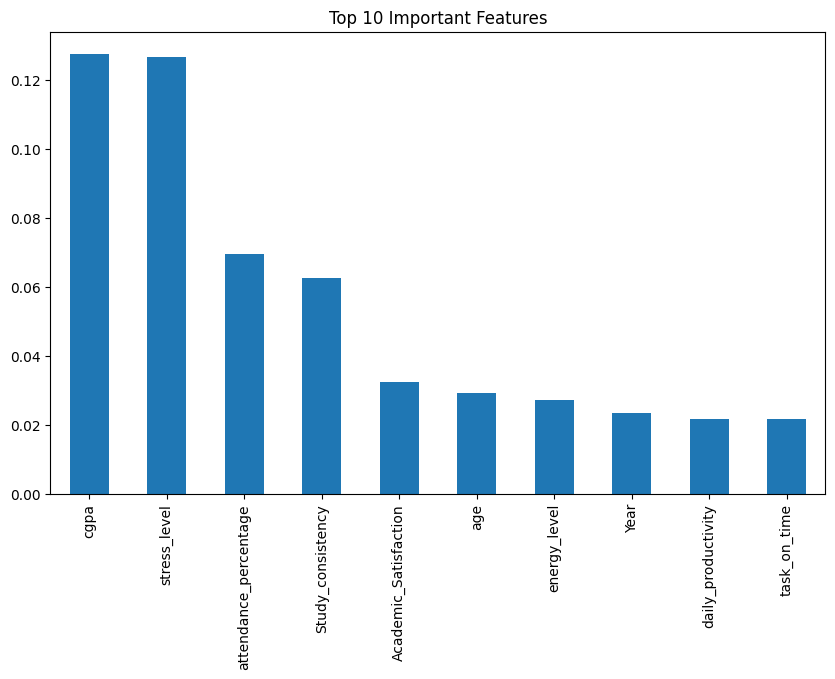

In [ ]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "student_performance_model.pkl")

['student_performance_model.pkl']